# Random Forest Model - Crop Recommendation

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Works whether run directly from Models/ OR via %run from project root (main.ipynb)
_cwd = os.getcwd()
_candidate1 = os.path.normpath(os.path.join(_cwd, 'Dataset', 'Processed', 'processed_crop_data.csv'))
_candidate2 = os.path.normpath(os.path.join(_cwd, '..', 'Dataset', 'Processed', 'processed_crop_data.csv'))

if os.path.exists(_candidate1):
    DATA_PATH = _candidate1
elif os.path.exists(_candidate2):
    DATA_PATH = _candidate2
else:
    raise FileNotFoundError(
        f'Could not find processed_crop_data.csv. Tried:\n  {_candidate1}\n  {_candidate2}'
    )

df = pd.read_csv(DATA_PATH)
print('Processed dataset loaded.')
print('Data path:', DATA_PATH)
print('Shape:', df.shape)
df.head()

Processed dataset loaded.
Data path: c:\Users\Acer\Downloads\CRP\Crop_Recommendation_System\Dataset\Processed\processed_crop_data.csv
Shape: (2253, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,37.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


## Feature & Target Setup

In [3]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']
print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nFirst few label values (before encoding):')
print(y.head(10))

Features (X) shape: (2253, 7)
Target (y) shape: (2253,)

First few label values (before encoding):
0    rice
1    rice
2    rice
3    rice
4    rice
5    rice
6    rice
7    rice
8    rice
9    rice
Name: label, dtype: str


## Label Encoding

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding mapping:')
print(mapping)

Label encoding mapping:
{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


## Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 1802
Test set size: 451


## Model Training

In [6]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## Evaluation

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.975609756097561

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        21
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.98        21
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        21
      cotton       1.00      0.95      0.98        21
      grapes       1.00      1.00      1.00        21
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        21
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        21
   mothbeans       0.95      0.95      0.95        21
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      0.95      0.98        21
      orange       1.00      

## Confusion Matrix

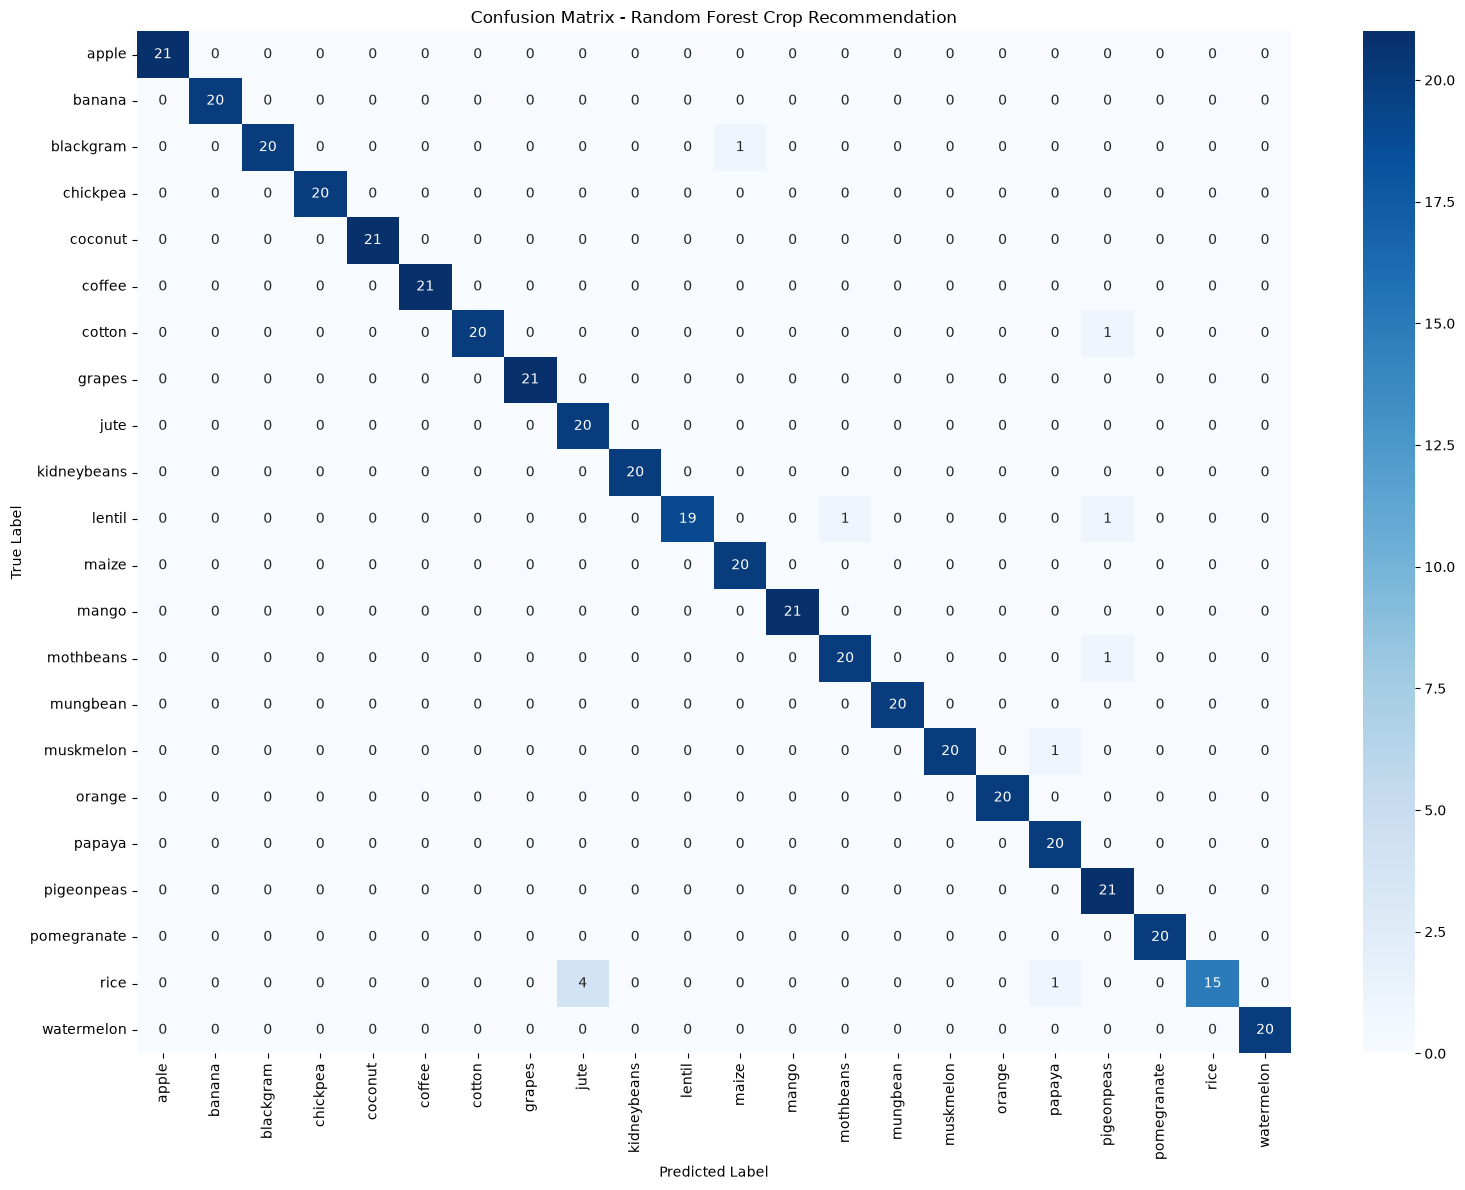

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('Confusion Matrix - Random Forest Crop Recommendation')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Importance

Feature Importances:
  N: 0.1025
  P: 0.1509
  K: 0.1707
  temperature: 0.0748
  humidity: 0.2161
  ph: 0.0553
  rainfall: 0.2299


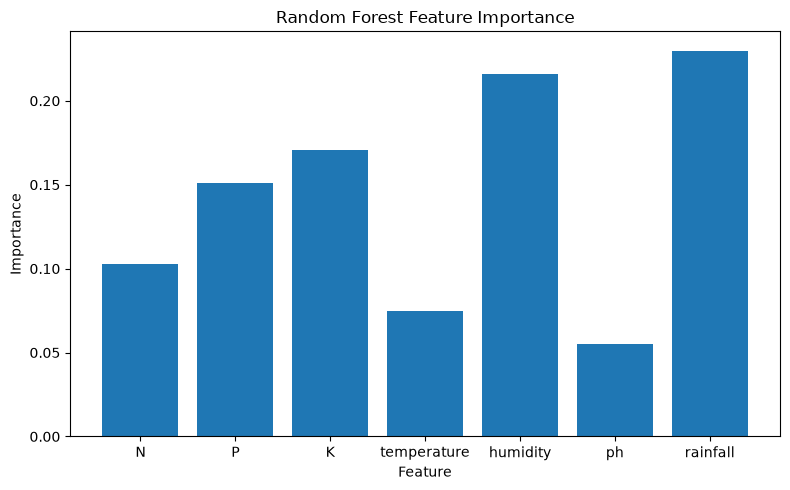

In [9]:
feature_names = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
importances = model.feature_importances_

print('Feature Importances:')
for name, importance in zip(feature_names, importances):
    print(f'  {name}: {importance:.4f}')

plt.figure(figsize=(8, 5))
plt.bar(feature_names, importances)
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Crop Prediction (Interactive)

In [13]:
print('Enter the soil and climate values to get a crop recommendation:')
N           = float(input('Enter Nitrogen value: '))
while True:
    ph = float(input('Enter pH value (1-10): '))
    if 1 <= ph <= 10:
        break
    print('Invalid pH! Must be between 1 and 10.')
K           = float(input('Enter Potassium value: '))
temperature = float(input('Enter Temperature: '))
humidity    = float(input('Enter Humidity: '))
while True:
    ph = float(input('Enter pH value (1-10): '))
    if 1 <= ph <= 10:
        break
    print('Invalid pH! Must be between 1 and 10.')
rainfall    = float(input('Enter Rainfall value: '))

user_input = [[N, P, K, temperature, humidity, ph, rainfall]]

prediction_encoded = model.predict(user_input)
predicted_crop = le.inverse_transform(prediction_encoded)

print('\nRecommended Crop:', predicted_crop[0])

Enter the soil and climate values to get a crop recommendation:

Recommended Crop: muskmelon


C:\Users\Acer\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
